# 01. Exploratory Data Analysis (EDA)
This notebook performs the initial exploratory data analysis on the IBM AML dataset (`HI-Small_Trans.csv` and `HI-Small_accounts.csv`).

**Goals:**
1. Descriptive Statistics
2. Data Visualization
3. Identify Issues (Missing values, Class Imbalance, Outliers)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

## 1. Data Loading

In [2]:
# Load the transactions dataset
# Note: Depending on RAM, this might take a minute as it's ~475MB.
trans_df = pd.read_csv('../data/raw/HI-Small_Trans.csv')
print(f"Transactions shape: {trans_df.shape}")
display(trans_df.head())

Transactions shape: (5078345, 11)


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


In [3]:
# Load the accounts dataset
acc_df = pd.read_csv('../data/raw/HI-Small_accounts.csv')
print(f"Accounts shape: {acc_df.shape}")
display(acc_df.head())

Accounts shape: (518581, 5)


,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
0,Portugal Bank #4507,331579,80B779D80,80062E240,Sole Proprietorship #50438
1,Canada Bank #27,210,809D86900,800C998A0,Corporation #33520
2,UK Bank #33,21884,80812BE00,800C47F50,Partnership #35397
3,Germany Bank #4815,32742,81047F300,80096F0B0,Corporation #48813
4,National Bank of Harrisburg,127390,80BD8CF00,800FB8760,Corporation #889


## 2. Descriptive Statistics
Let's look at the data types and summary statistics.

In [4]:
trans_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           str    
 1   From Bank           int64  
 2   Account             str    
 3   To Bank             int64  
 4   Account.1           str    
 5   Amount Received     float64
 6   Receiving Currency  str    
 7   Amount Paid         float64
 8   Payment Currency    str    
 9   Payment Format      str    
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), str(6)
memory usage: 699.6 MB


In [5]:
trans_df.describe()

,From Bank,To Bank,Amount Received,Amount Paid,Is Laundering
count,5.078345e+06,5.078345e+06,5.078345e+06,5.078345e+06,5.078345e+06
mean,4.573057e+04,6.574456e+04,5.988726e+06,4.509273e+06,1.019427e-03
std,8.176562e+04,8.409299e+04,1.037183e+09,8.697728e+08,3.191219e-02
min,1.000000e+00,1.000000e+00,1.000000e-06,1.000000e-06,0.000000e+00
25%,1.190000e+02,4.259000e+03,1.833700e+02,1.844800e+02,0.000000e+00
50%,9.679000e+03,2.156800e+04,1.411010e+03,1.414540e+03,0.000000e+00
75%,2.862800e+04,1.223320e+05,1.234627e+04,1.229784e+04,0.000000e+00
max,3.563030e+05,3.562940e+05,1.046302e+12,1.046302e+12,1.000000e+00


### Class Imbalance
Money laundering is an anomaly. We need to quantify the exact class imbalance.

In [6]:
target_counts = trans_df['Is Laundering'].value_counts()
imbalance_ratio = target_counts[0] / target_counts[1]
print(f"Class Distribution:\n{target_counts}\n")
print(f"Ratio: 1 illicit transaction for every {imbalance_ratio:.0f} normal transactions.")

Class Distribution:
Is Laundering
0    5073168
1       5177
Name: count, dtype: int64

Ratio: 1 illicit transaction for every 980 normal transactions.


## 3. Data Visualization

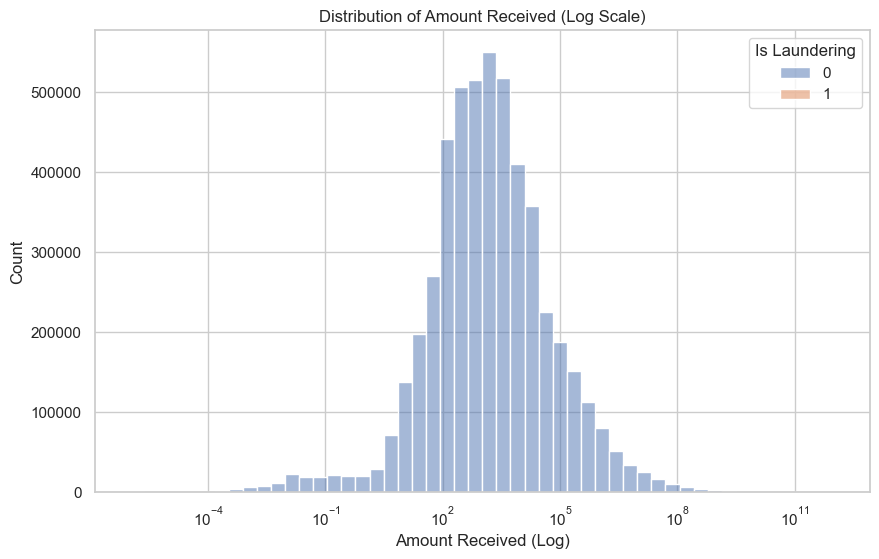

In [7]:
# 3.1 Amount Received Distribution (Log Scale)
plt.figure(figsize=(10, 6))
sns.histplot(data=trans_df, x='Amount Received', hue='Is Laundering', bins=50, log_scale=True)
plt.title('Distribution of Amount Received (Log Scale)')
plt.xlabel('Amount Received (Log)')
plt.ylabel('Count')
plt.show()

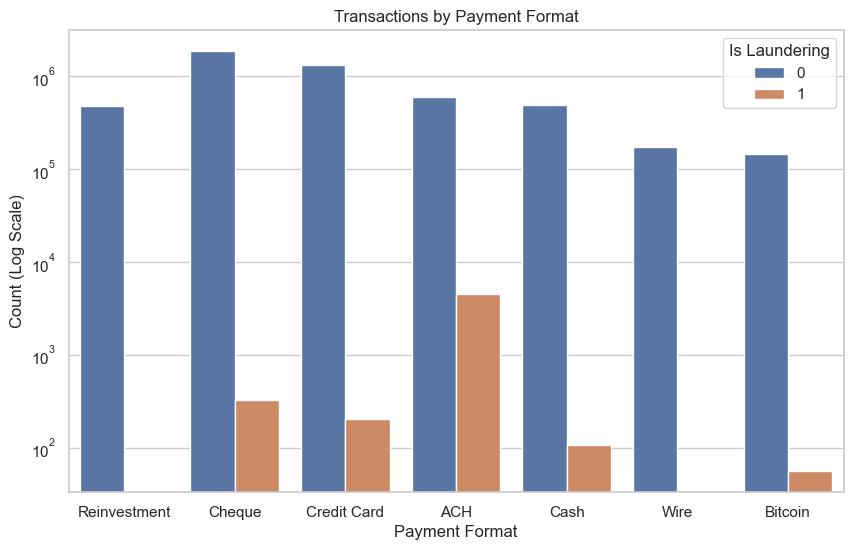

In [8]:
# 3.2 Payment Format vs Laundering
plt.figure(figsize=(10, 6))
sns.countplot(data=trans_df, x='Payment Format', hue='Is Laundering')
plt.title('Transactions by Payment Format')
plt.yscale('log') # Log scale because normal transactions dwarf illicit ones
plt.ylabel('Count (Log Scale)')
plt.show()

## 4. Identify Issues
We need to check for missing values, duplicates, and formulate a strategy for the class imbalance.

In [9]:
missing_values = trans_df.isnull().sum()
print("Missing Values:\n", missing_values[missing_values > 0])
if missing_values.sum() == 0:
    print("No missing values found in transactions.")

Missing Values:
 Series([], dtype: int64)
No missing values found in transactions.


In [10]:
duplicates = trans_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 9


### Summary of Identified Issues:
1. **Extreme Class Imbalance:** We have roughly 1 illicit transaction per 1,750 normal transactions. Standard accuracy will fail here. We must use PR-AUC and likely need SMOTE, Class Weights, or graph-based structural modeling (like GNNs).
2. **Highly Skewed Features:** Features like `Amount Received` and `Amount Paid` are highly skewed (many small transactions, few massive ones). We will need feature scaling (e.g., Log Transformation, RobustScaler) in Step 4.
3. **Temporal Features Need Extraction:** The `Timestamp` is a string. In Step 4 (Feature Engineering), we will need to parse this to extract `Day of Week`, `Hour`, or `Time Since Last Transaction`.